## Import Libraries


In [38]:
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Device Setup

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Data Loading and Preprocessing

In [3]:
transform = torchvision.transforms.Compose([
            torchvision.transforms.Resize((224,224)),
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.299, 0.224,0.225])
])

In [7]:
train_datasets = torchvision.datasets.ImageFolder(fr"Chest_X-ray_Dataset\train", transform=transform)
val_datasets = torchvision.datasets.ImageFolder(fr"Chest_X-ray_Dataset\val", transform=transform)
test_datasets = torchvision.datasets.ImageFolder(fr"Chest_X-ray_Dataset\test", transform=transform)

In [8]:
train_datasets.classes

['NORMAL', 'PNEUMONIA']

In [13]:
train_dataloader = DataLoader(train_datasets, batch_size=8, shuffle = True)
val_dataloader = DataLoader(val_datasets, batch_size=8, shuffle = False)
test_dataloader = DataLoader(test_datasets, batch_size=8, shuffle = False)

In [14]:
for images,labels in train_dataloader:
    print(images)
    print(labels)
    break

tensor([[[[-1.6221, -1.6090, -1.4909,  ..., -0.6777, -0.7302, -0.7958],
          [-1.6221, -1.6090, -1.5040,  ..., -0.6777, -0.7302, -0.7696],
          [-1.6221, -1.6090, -1.5171,  ..., -0.6909, -0.7433, -0.7827],
          ...,
          [-1.6221, -1.6221, -1.6221,  ..., -1.6221, -1.6221, -1.6221],
          [-1.6221, -1.6221, -1.6221,  ..., -1.6221, -1.6221, -1.6221],
          [-1.6221, -1.6221, -1.6221,  ..., -1.6221, -1.6221, -1.6221]],

         [[-2.0357, -2.0182, -1.8606,  ..., -0.7752, -0.8452, -0.9328],
          [-2.0357, -2.0182, -1.8782,  ..., -0.7752, -0.8452, -0.8978],
          [-2.0357, -2.0182, -1.8957,  ..., -0.7927, -0.8627, -0.9153],
          ...,
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],

         [[-1.8044, -1.7870, -1.6302,  ..., -0.5495, -0.6193, -0.7064],
          [-1.8044, -1.7870, -

In [15]:
for images, labels in train_dataloader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([8, 3, 224, 224])
torch.Size([8])


## Data Sample Visualizaton

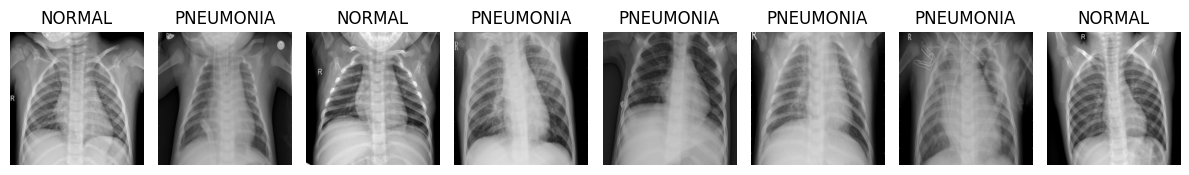

In [24]:
images, labels = next(iter(train_dataloader))
classes = train_datasets.classes

mean = [0.485, 0.456, 0.406]
std = [0.299, 0.224,0.225]

fig, axes = plt.subplots(1,8, figsize = (12,8))
for i, ax in enumerate(axes.flat):
    img = images[i].numpy().transpose((1,2,0))
    img = (img*std)+mean
    img = np.clip(img, 0, 1)
    ax.imshow(img.squeeze(), cmap= "gray")
    ax.set_title(classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Model

In [33]:

model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 2)

model= model.to(device=device)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\sanje/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:07<00:00, 5.97MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [34]:
from torchinfo import summary
summary(model, input_size=(8,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [8, 2]                    --
├─Conv2d: 1-1                            [8, 64, 112, 112]         (9,408)
├─BatchNorm2d: 1-2                       [8, 64, 112, 112]         (128)
├─ReLU: 1-3                              [8, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [8, 64, 56, 56]           --
├─Sequential: 1-5                        [8, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [8, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [8, 64, 56, 56]           (36,864)
│    │    └─BatchNorm2d: 3-2             [8, 64, 56, 56]           (128)
│    │    └─ReLU: 3-3                    [8, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [8, 64, 56, 56]           (36,864)
│    │    └─BatchNorm2d: 3-5             [8, 64, 56, 56]           (128)
│    │    └─ReLU: 3-6                    [8, 64, 56, 56]   

## Optimizer and Loss Function

In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr = 0.001)

## Training Loop

In [37]:
epochs = 5

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    train_loss = 0.0

    correct = 0
    total = 0 

    print(f"Epoch : {epoch+1}/{epochs}")
    train_bar = tqdm(train_dataloader, desc = f"Training")

    for images, labels in train_bar:

        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()
        
        running_train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        acc = correct/total

        train_bar.set_postfix(loss = loss.item(), acc = acc)
    
    train_loss = running_train_loss/len(train_dataloader)
    train_acc = correct/total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    #validation
    model.eval()
    running_val_loss = 0.0
    val_loss = 0.0

    correct = 0
    total = 0

    val_bar = tqdm(val_dataloader, desc = "Validation")

    with torch.no_grad():
        for images,labels in val_bar:
            images , labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
        
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_bar.set_postfix(loss = loss.item())
        
        val_loss = running_val_loss/len(val_dataloader)
        val_acc = correct/ total

        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Train Loss = {train_loss:.4f}  | Train Accuracy = {train_acc:.4f}")  
        print(f"Validation Loss = {val_loss:.4f}  | Validation Accuracy = {val_acc:.4f}")  

Epoch : 1/5


Validation: 100%|██████████| 2/2 [00:00<00:00,  2.51it/s, loss=0.0133]


Train Loss = 0.2481  | Train Accuracy = 0.8972
Validation Loss = 0.5982  | Validation Accuracy = 0.5625
Epoch : 2/5


Validation: 100%|██████████| 2/2 [00:00<00:00,  3.92it/s, loss=0.0178]


Train Loss = 0.2050  | Train Accuracy = 0.9189
Validation Loss = 0.3553  | Validation Accuracy = 0.8125
Epoch : 3/5


...

Train Loss = 0.1699  | Train Accuracy = 0.9291
Validation Loss = 0.5412  | Validation Accuracy = 0.6875
Epoch : 4/5


Validation: 100%|██████████| 2/2 [00:00<00:00,  4.79it/s, loss=0.00531]


Train Loss = 0.1531  | Train Accuracy = 0.9387
Validation Loss = 0.5275  | Validation Accuracy = 0.6875
Epoch : 5/5


Validation: 100%|██████████| 2/2 [00:00<00:00,  4.31it/s, loss=0.00921]

Train Loss = 0.1784  | Train Accuracy = 0.9304
Validation Loss = 0.3892  | Validation Accuracy = 0.8125


## Save Model

In [39]:
torch.save(model.state_dict(), "model.pt")

## Loss and Accuracy Curve

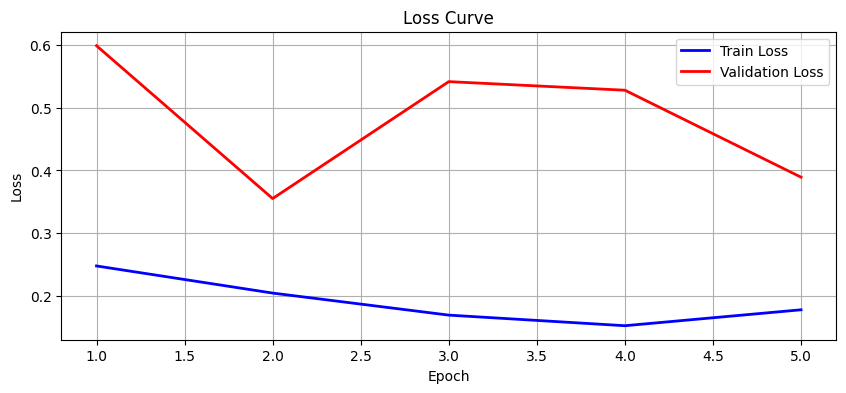

In [40]:
epochs = range(1,len(train_losses)+1)
plt.figure(figsize = (10,4))

#Loss
plt.plot(epochs, train_losses, label ="Train Loss", color ="blue", linewidth = 2)
plt.plot(epochs, val_losses, label = "Validation Loss", color = "red", linewidth = 2)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

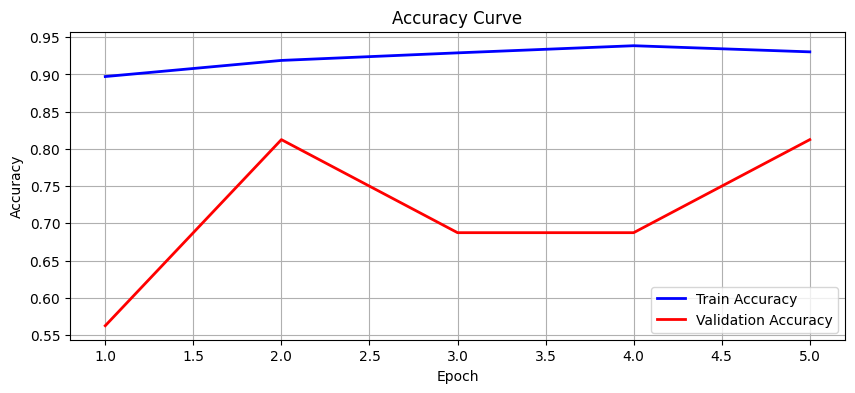

In [41]:
plt.figure(figsize = (10,4))

#Accuracy
plt.plot(epochs, train_accuracies, label ="Train Accuracy", color ="blue", linewidth = 2)
plt.plot(epochs, val_accuracies, label = "Validation Accuracy", color = "red", linewidth = 2)
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Test Evaluation

In [42]:
model.load_state_dict(torch.load("model.pt", map_location=device))
model.eval()
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [43]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images,labels in test_dataloader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs,1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [44]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = (all_preds == all_labels).mean() * 100

print("Test Accuracy:", accuracy)

Test Accuracy: 85.57692307692307


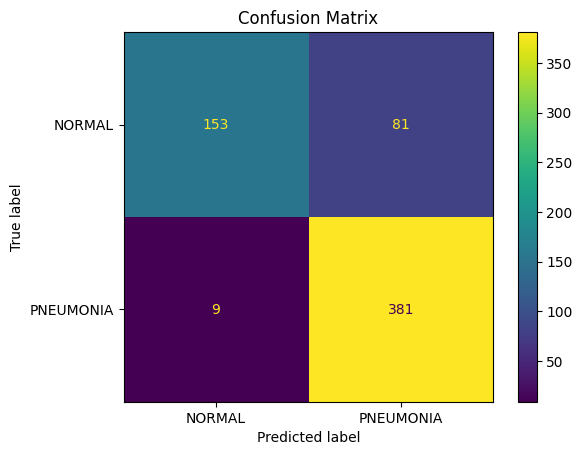

In [45]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_datasets.classes)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

## Infrence

In [46]:
from PIL import Image
import torch.nn.functional as F

def predict_image(image_path, model, transform, class_names):
    img = Image.open(image_path).convert("RGB")

    img_t = transform(img)

    img_t = img_t.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_t)

        probs = F.softmax(outputs, dim = 1)

        conf, pred = torch.max(probs, 1)

    predicted_label = class_names[pred.item()]

    confidence = conf.item()*100

    plt.imshow(img)
    plt.title(f"Predicted: {predicted_label}({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

    return predicted_label, confidence

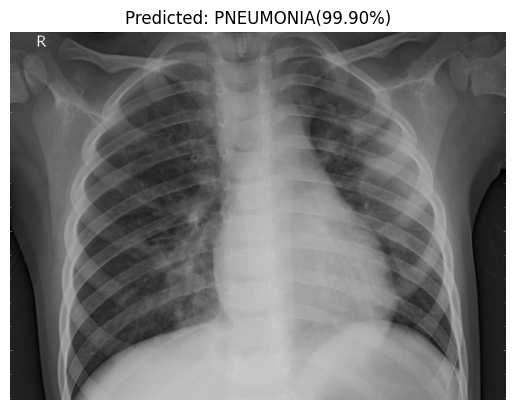

Predicted Label : PNEUMONIA, Confidence : 99.90


In [49]:
image_path = fr"D:\Pheumonia_Detection_From_X-rays\Chest_X-ray_Dataset\test\PNEUMONIA\person3_virus_15.jpeg"

predicted_label, confidence = predict_image(image_path, model, transform,test_datasets.classes)

print(f"Predicted Label : {predicted_label}, Confidence : {confidence:.2f}")